In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

Pierwsze wiersze danych:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
5 -0.092695 -0.044642 -0.040696 -0.019442 -0.068991 -0.079288  0.041277   
6 -0.045472  0.050680 -0.047163 -0.015999 -0.040096 -0.024800  0.000779   
7  0.063504  0.050680 -0.001895  0.066629  0.090620  0.108914  0.022869   
8  0.041708  0.050680  0.061696 -0.040099 -0.013953  0.006202 -0.028674   
9 -0.070900 -0.044642  0.039062 -0.033213 -0.012577 -0.034508 -0.024993   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -

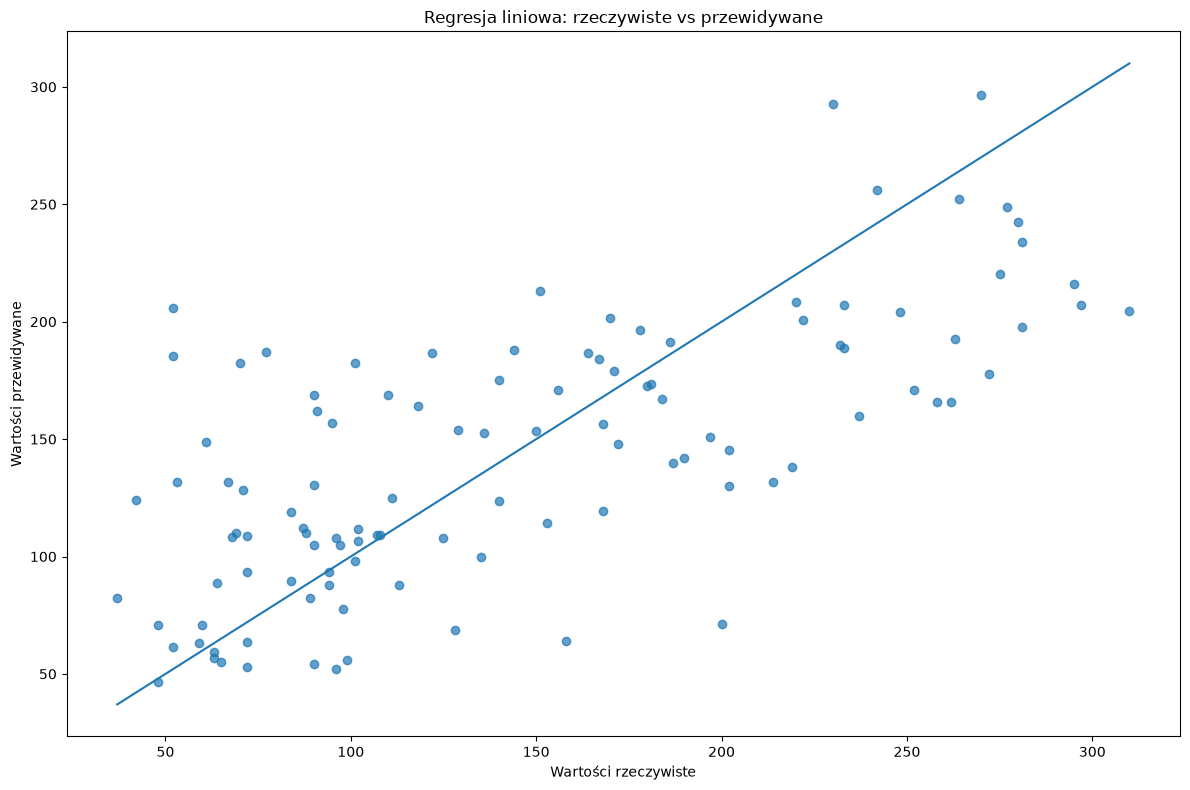

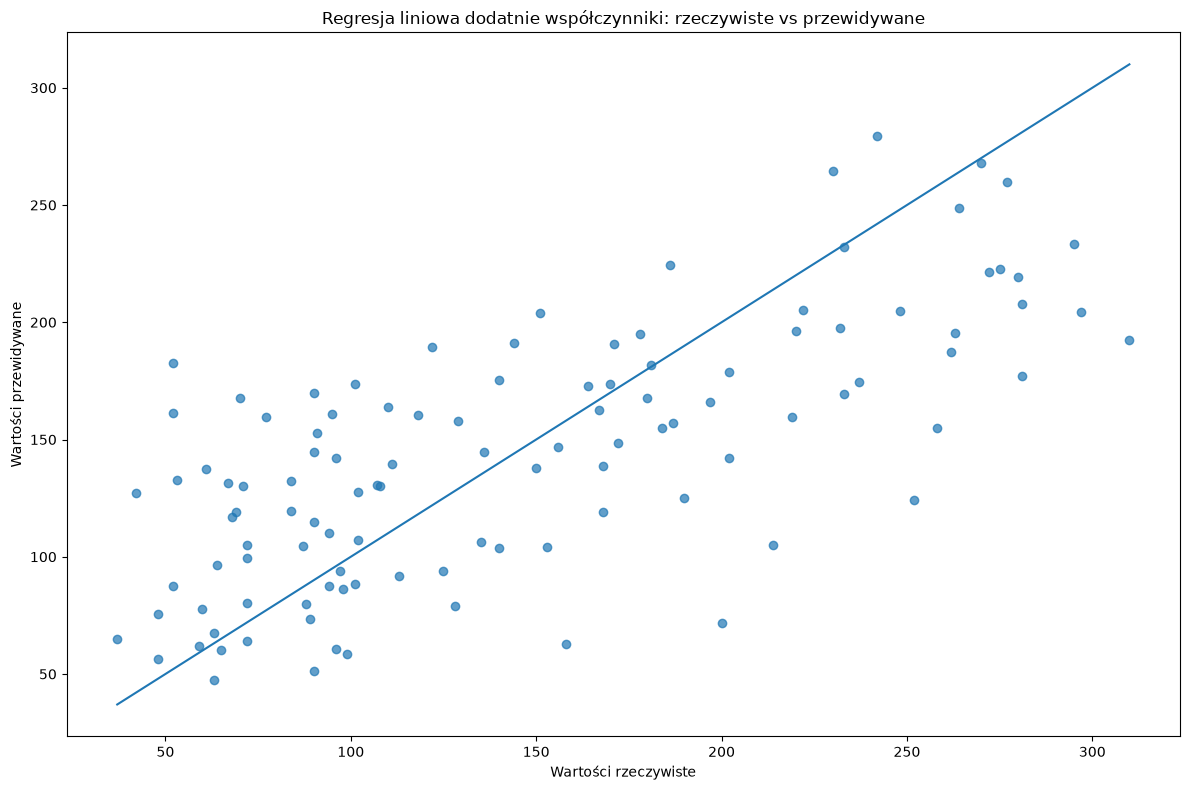

Interpretacja
1. Im bliżej punkty są na linii przekątnej, tym lepsze predykcje
2. MAE mówi o przeciętnym błędzie w jednostkach zmiennej docelowej
3. R2 pokazuje, jaka część zmienności została wyjaśniona


In [24]:
zbior = load_diabetes(as_frame=True)

X = zbior.data
y = zbior.target

print("Pierwsze wiersze danych:")
print(zbior.frame.head(10))

print("Kształt cech X:", X.shape)
print("Kształt celu y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Współczynniki modelu:")
wspolczynniki = pd.Series(model.coef_, index=X.columns)
print(wspolczynniki.sort_values(ascending=False))

print("Wyraz wolny modelu:")
print(round(model.intercept_, 3))

print("Metryki oceny:")

print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R2:", round(r2, 3))

wyniki = pd.DataFrame({
    "rzeczywiste": y_test.values,
    "przewidywane": y_pred,
})

wyniki["blad"] = wyniki["rzeczywiste"] - wyniki["przewidywane"]

print("Pierwsze 10 wyników")
print(wyniki.head(10))

model_dodatni = LinearRegression(positive=True)

model_dodatni.fit(X_train, y_train)

y_pred_dodatni = model_dodatni.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_dodatni)
mse = mean_squared_error(y_test, y_pred_dodatni)
r2 = r2_score(y_test, y_pred_dodatni)

print("Współczynniki modelu dodatniego:")
wspolczynniki = pd.Series(model_dodatni.coef_, index=X.columns)
print(wspolczynniki.sort_values(ascending=False))

print("Wyraz wolny modelu dodatniego:")
print(round(model_dodatni.intercept_, 3))

print("Metryki oceny modelu dodatniego:")

print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R2:", round(r2, 3))

wyniki = pd.DataFrame({
    "rzeczywiste": y_test.values,
    "przewidywane": y_pred_dodatni,
})

wyniki["blad"] = wyniki["rzeczywiste"] - wyniki["przewidywane"]

print("Pierwsze 10 wyników modelu dodatniego:")
print(wyniki.head(10))

plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel("Wartości rzeczywiste")
plt.ylabel("Wartości przewidywane")

plt.title("Regresja liniowa: rzeczywiste vs przewidywane")

plt.tight_layout()

plt.show()

plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred_dodatni, alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel("Wartości rzeczywiste")
plt.ylabel("Wartości przewidywane")

plt.title("Regresja liniowa dodatnie współczynniki: rzeczywiste vs przewidywane")

plt.tight_layout()

plt.show()

print("Interpretacja")
print("1. Im bliżej punkty są na linii przekątnej, tym lepsze predykcje")
print("2. MAE mówi o przeciętnym błędzie w jednostkach zmiennej docelowej")
print("3. R2 pokazuje, jaka część zmienności została wyjaśniona")